Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Reading in the titanic_train.csv file into a pandas dataframe.

In [ ]:
train = pd.read_csv('titanic_train.csv')

In [ ]:
X_test=pd.read_csv('/content/test_titanic.csv')
y_test=pd.read_csv('/content/gender_submission.csv')

In [ ]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
train['Name'].is_unique


True

In [ ]:
train[train['Name'].duplicated()]['Name']


,Name


Name is Unique Element


is there any missing data??


In [ ]:
train.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:

train.isnull().values.any()


np.True_

<Axes: >

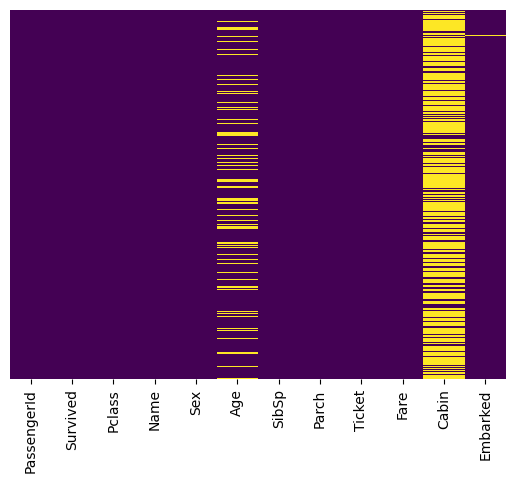

In [ ]:
sns.heatmap(train.isnull(),yticklabels=False,cbar=False,cmap='viridis')

Age,embarked(very less) and Cabin column consist Nan Value. Cabin Column mostly have Nan Value so I drop the column

<Axes: xlabel='Survived', ylabel='count'>

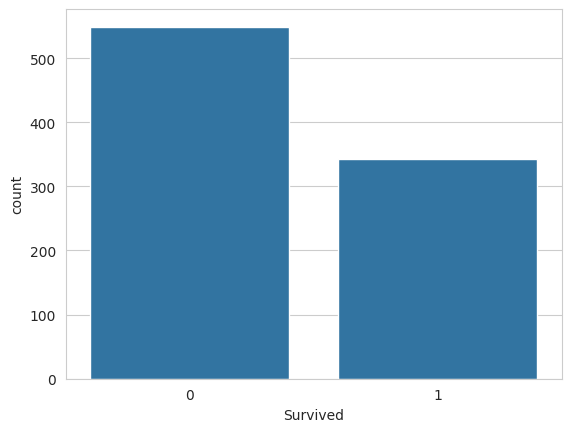

In [ ]:
sns.set_style('whitegrid')
sns.countplot(x='Survived',data=train)

In [ ]:
train['Survived'].value_counts()

,count
Survived,
0,549
1,342


##Imbalance dataset


<Axes: xlabel='Survived', ylabel='count'>

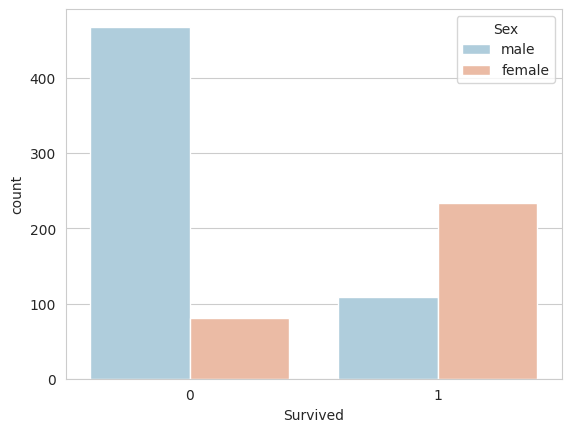

In [ ]:
sns.set_style('whitegrid')
sns.countplot(x='Survived',hue='Sex',data=train,palette='RdBu_r')

This clearly shows that a lot of females survived over males .

<Axes: xlabel='Survived', ylabel='count'>

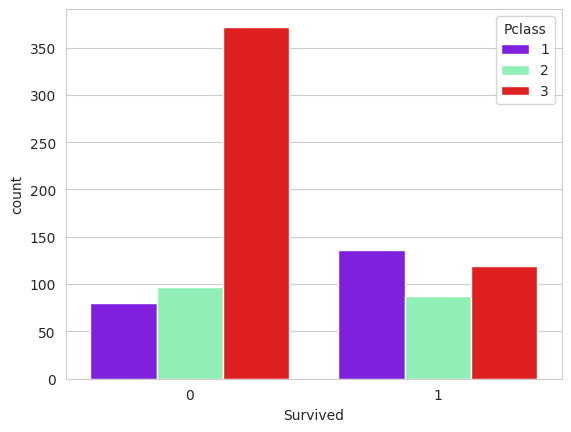

In [ ]:
sns.set_style('whitegrid')
sns.countplot(x='Survived',hue='Pclass',data=train,palette='rainbow')

/tmp/ipython-input-2002818437.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['Age'].dropna(),kde=False,color='darkred',bins=40)


<Axes: xlabel='Age'>

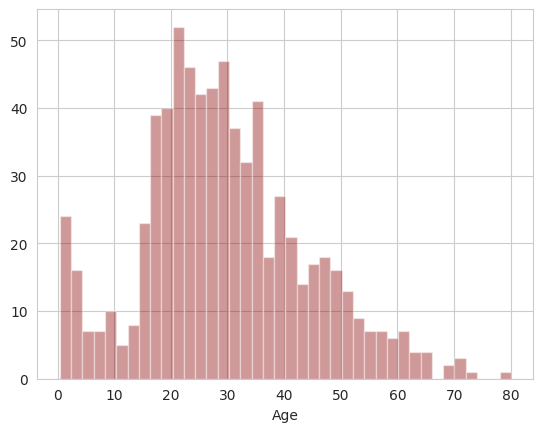

In [ ]:
sns.distplot(train['Age'].dropna(),kde=False,color='darkred',bins=40)

<Axes: >

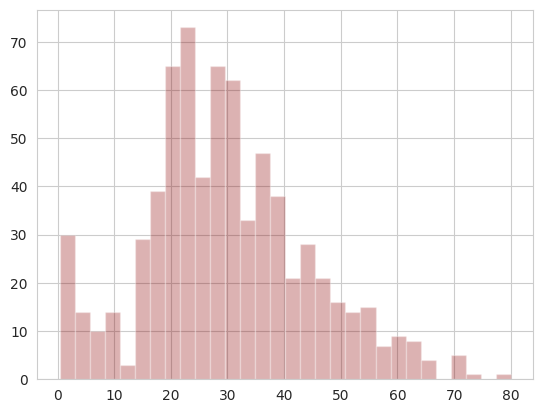

In [ ]:
train['Age'].hist(bins=30,color='darkred',alpha=0.3)

<Axes: xlabel='SibSp', ylabel='count'>

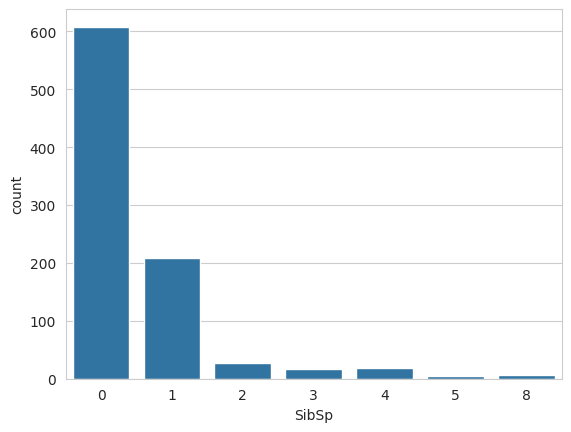

In [ ]:
sns.countplot(x='SibSp',data=train)

<Axes: >

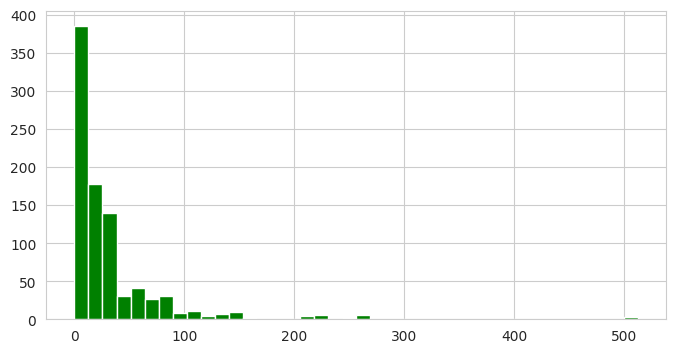

In [ ]:
train['Fare'].hist(color='green',bins=40,figsize=(8,4))

Deal with the Age(as this is the most important factor to determine target(survived/not survived)) dataset

/tmp/ipython-input-1683851715.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass',y='Age',data=train,palette='winter')


<Axes: xlabel='Pclass', ylabel='Age'>

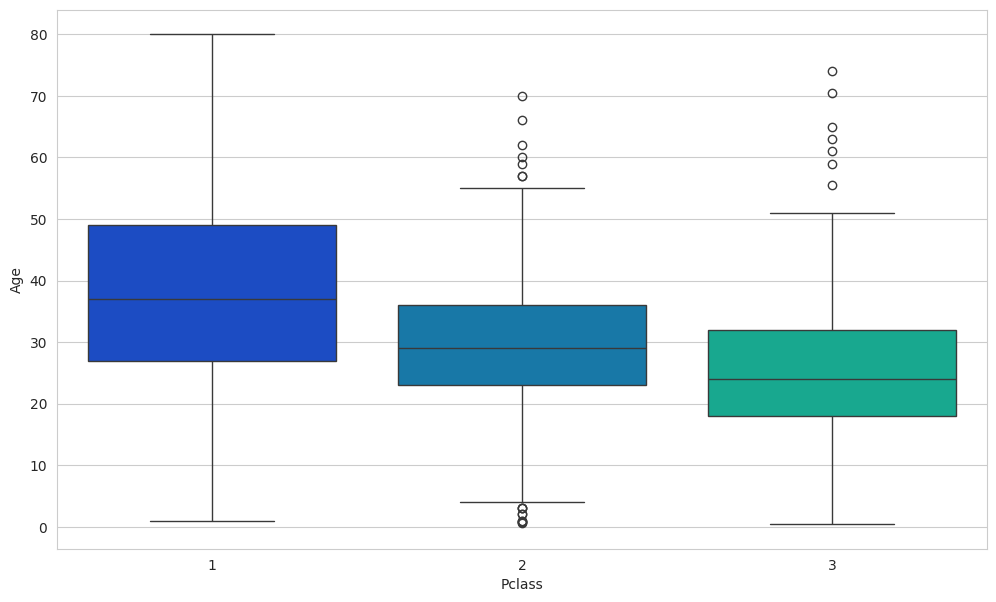

In [ ]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='Pclass',y='Age',data=train,palette='winter')

The average age for Pclass 1 is around 38 where as for other classes its 29 and 23 respectively


I'll use these average age values to impute based on Pclass for Age.


In [ ]:
def impute_age(cols):
    Age = cols[0]
    Pclass = cols[1]

    if pd.isnull(Age):

        if Pclass == 1:
            return 37

        elif Pclass == 2:
            return 29

        else:
            return 24

    else:
        return Age

In [ ]:
train['Age'] = train[['Age','Pclass']].apply(impute_age,axis=1)

/tmp/ipython-input-822839471.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Age = cols[0]
/tmp/ipython-input-822839471.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Pclass = cols[1]


I have replaced the values of Age column with their respective mean values.

In [ ]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [ ]:
train['PassengerId'].is_unique

True

In [ ]:
train['Ticket'].is_unique

False

In [ ]:
train.drop(['PassengerId','Ticket','Cabin','Name'],inplace=True,axis=1)

In [ ]:
X_test.drop(['PassengerId','Ticket','Cabin','Name'],inplace=True,axis=1)

<Axes: >

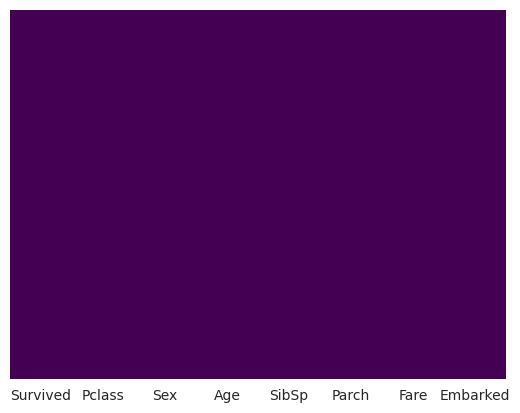

In [ ]:
sns.heatmap(train.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [ ]:
train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [ ]:
train.dropna(inplace=True)

Remove the Nan value and repeat the same process on X_test dataset

In [ ]:
def Age_1(cols) :
    Age=cols[0]
    Pclass=cols[1]

    if pd.isnull(Age) :
        if Pclass==1 :
            return 42
        elif Pclass==2:
            return 25
        else :
            return 22
    else :
        return Age


In [ ]:
X_test['Age']=X_test[['Age','Pclass']].apply(Age_1,axis=1)

/tmp/ipython-input-2144672487.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Age=cols[0]
/tmp/ipython-input-2144672487.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Pclass=cols[1]


/tmp/ipython-input-2454231697.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['Fare'],bins=40)


<Axes: xlabel='Fare', ylabel='Density'>

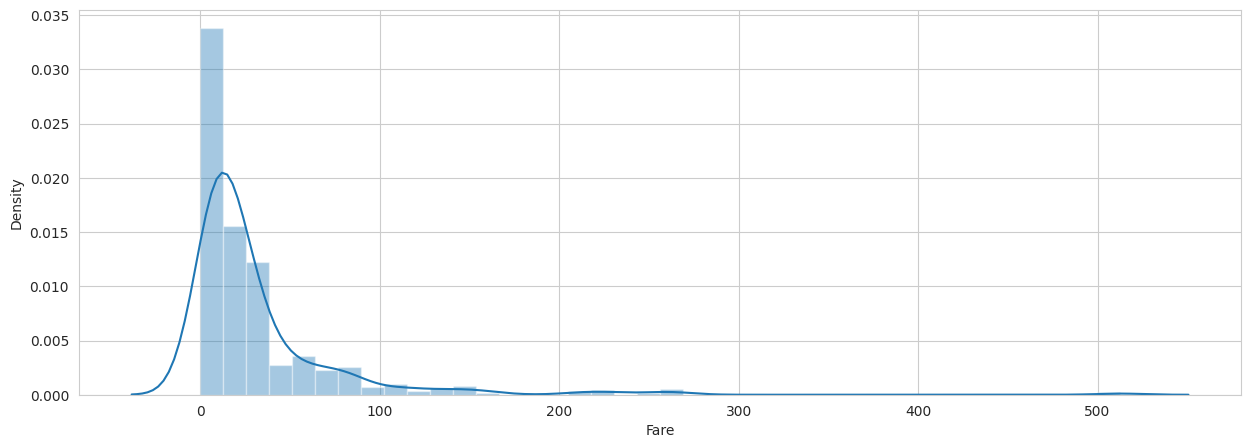

In [ ]:
plt.figure(figsize=(15,5))
sns.distplot(train['Fare'],bins=40)

/tmp/ipython-input-836035783.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train_fare,bins=40)


<Axes: xlabel='Fare', ylabel='Density'>

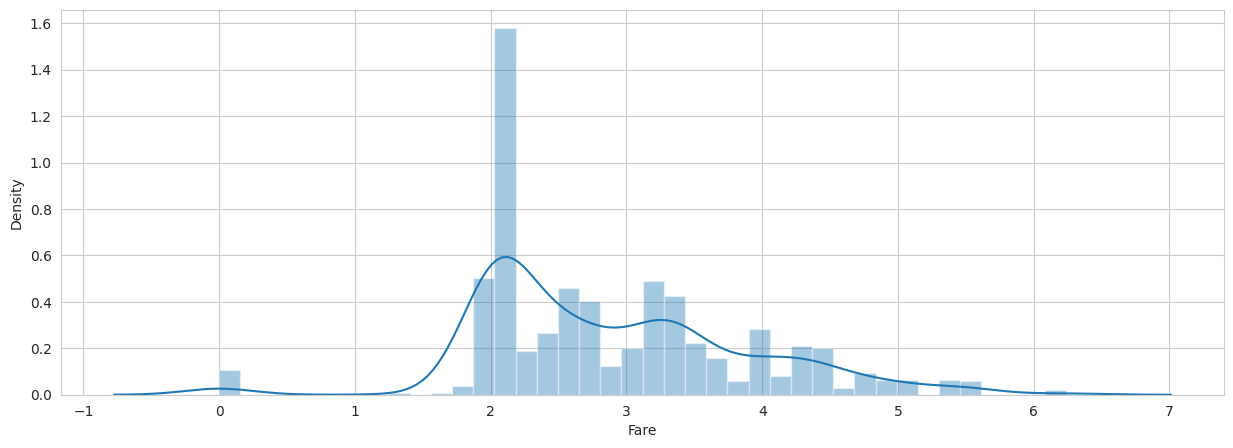

In [ ]:
train_fare = train['Fare'].map(lambda i: np.log(i) if i > 0 else 0)
plt.figure(figsize=(15,5))
sns.distplot(train_fare,bins=40)

Now look like proper gaussian function

In [ ]:
fare=train['Fare'].map(lambda i: np.log(i) if i > 0 else 0)

In [ ]:
print (fare)

0      1.981001
1      4.266662
2      2.070022
3      3.972177
4      2.085672
         ...   
886    2.564949
887    3.401197
888    3.154870
889    3.401197
890    2.047693
Name: Fare, Length: 889, dtype: float64


Categorical Features

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  889 non-null    int64  
 1   Pclass    889 non-null    int64  
 2   Sex       889 non-null    object 
 3   Age       889 non-null    float64
 4   SibSp     889 non-null    int64  
 5   Parch     889 non-null    int64  
 6   Fare      889 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 62.5+ KB


One hot encoding for converting categorical features into binary format

In [ ]:
sex=pd.get_dummies(train['Sex'],drop_first=True)
emb=pd.get_dummies(train['Embarked'],drop_first=True)

In [ ]:
y_train=train['Survived']
train.drop(['Embarked','Sex','Survived','Fare'],inplace=True,axis=1)

In [ ]:
X_train=pd.concat([train,sex,emb,fare],axis=1)

In [ ]:
y_test.drop('PassengerId',inplace=True,axis=1)

In [ ]:
X_train

,Pclass,Age,SibSp,Parch,male,Q,S,Fare
0,3,22.0,1,0,True,False,True,1.981001
1,1,38.0,1,0,False,False,False,4.266662
2,3,26.0,0,0,False,False,True,2.070022
3,1,35.0,1,0,False,False,True,3.972177
4,3,35.0,0,0,True,False,True,2.085672
...,...,...,...,...,...,...,...,...
886,2,27.0,0,0,True,False,True,2.564949
887,1,19.0,0,0,False,False,True,3.401197
888,3,24.0,1,2,False,False,True,3.154870
889,1,26.0,0,0,True,False,False,3.401197


This is our final dataset for training the dataset and same goes for y_train .
I have to perform the following steps on X_test i.e. test data as well bcz even it contains some of the data like this .Repeat the steps

In [ ]:
test_fare=X_test['Fare'].map(lambda i: np.log(i) if i > 0 else 0)

In [ ]:
test_sex=pd.get_dummies(X_test['Sex'],drop_first=True)
test_emb=pd.get_dummies(X_test['Embarked'],drop_first=True)
X_test.drop(['Embarked','Sex','Fare'],inplace=True,axis=1)
X_test=pd.concat([X_test,test_sex,test_emb,test_fare],axis=1)

In [ ]:
Y_test=pd.concat([X_test,test_sex,test_emb,test_fare,y_test],axis=1)
Y_test=Y_test.dropna(axis=0,how='any')

In [ ]:
y_test=Y_test['Survived']

Using Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [ ]:
lgr=LogisticRegression(max_iter=500)
lgr_train=lgr.fit(X_train,y_train)
y_pred_lr = lgr.predict(X_test)

In [ ]:
print(accuracy_score(y_test,y_pred_lr))
print(classification_report(y_test,y_pred_lr))
print(confusion_matrix(y_test,y_pred_lr))

0.930622009569378
              precision    recall  f1-score   support

           0       0.95      0.94      0.95       266
           1       0.90      0.91      0.91       152

    accuracy                           0.93       418
   macro avg       0.92      0.93      0.93       418
weighted avg       0.93      0.93      0.93       418

[[250  16]
 [ 13 139]]


using Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rnd_clf=RandomForestClassifier(n_estimators=1300,max_leaf_nodes=18,n_jobs=-1)
rnd_clf.fit(X_train,y_train)
y_pred_rf=rnd_clf.predict(X_test)

In [ ]:
print(accuracy_score(y_test,y_pred_rf))
print(classification_report(y_test,y_pred_rf))
print(confusion_matrix(y_test,y_pred_rf))

0.8923444976076556
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       266
           1       0.93      0.76      0.84       152

    accuracy                           0.89       418
   macro avg       0.90      0.86      0.88       418
weighted avg       0.90      0.89      0.89       418

[[257   9]
 [ 36 116]]


Using SVM

In [ ]:
from sklearn.svm import SVC

svm_clf = SVC(
    kernel="rbf",
    C=5,
    gamma="scale",
    class_weight="balanced",   # handle imbalance
    random_state=42
)

svm_clf.fit(X_train, y_train)
y_pred_svm = svm_clf.predict(X_test)


In [ ]:
print(accuracy_score(y_test,y_pred_svm))
print(classification_report(y_test,y_pred_svm))
print(confusion_matrix(y_test,y_pred_svm))

0.854066985645933
              precision    recall  f1-score   support

           0       0.95      0.81      0.88       266
           1       0.74      0.93      0.82       152

    accuracy                           0.85       418
   macro avg       0.84      0.87      0.85       418
weighted avg       0.87      0.85      0.86       418

[[216  50]
 [ 11 141]]


Using KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier(
    n_neighbors=7,
    weights="distance",   # better than uniform
    metric="minkowski"    # Euclidean distance
)

knn_clf.fit(X_train, y_train)
y_pred_knn = knn_clf.predict(X_test)


In [ ]:
print(accuracy_score(y_test,y_pred_knn))
print(classification_report(y_test,y_pred_knn))
print(confusion_matrix(y_test,y_pred_knn))

0.7416267942583732
              precision    recall  f1-score   support

           0       0.80      0.79      0.80       266
           1       0.64      0.66      0.65       152

    accuracy                           0.74       418
   macro avg       0.72      0.72      0.72       418
weighted avg       0.74      0.74      0.74       418

[[210  56]
 [ 52 100]]


In [ ]:
model_scores = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "SVM": accuracy_score(y_test, y_pred_svm),
    "KNN": accuracy_score(y_test, y_pred_knn),

}

results_df = pd.DataFrame(
    model_scores.items(),
    columns=["Model", "Accuracy"]
)

results_df

,Model,Accuracy
0,Logistic Regression,0.930622
1,Random Forest,0.892344
2,SVM,0.854067
3,KNN,0.741627


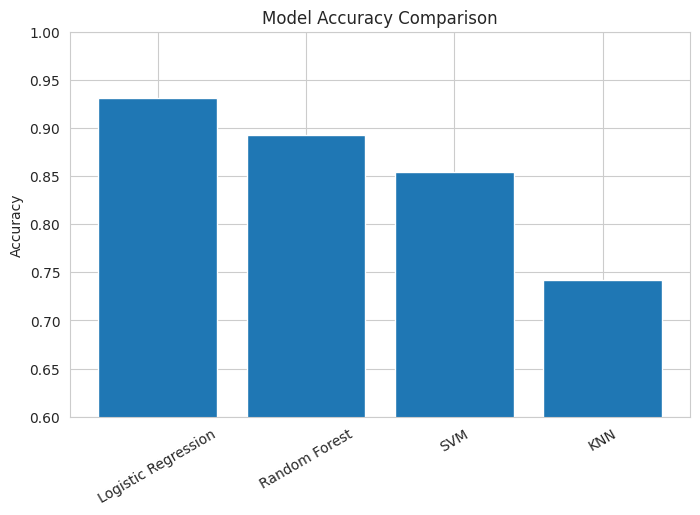

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=30)
plt.ylim(0.6, 1.0)
plt.show()


In [ ]:
best_model = results_df.loc[results_df["Accuracy"].idxmax()]
print("Best Model:")
print(best_model)


Best Model:
Model       Logistic Regression
Accuracy               0.930622
Name: 0, dtype: object
